In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import PercentFormatter
from statsmodels.stats.weightstats import DescrStatsW

plt.style.use('seaborn-v0_8')

In [2]:
data = pd.read_csv('smaller.csv', dtype={'SOCP': str})
data['inc2024'] = data.PINCP * data.ADJINC / 1_000_000
print(data.shape, data.PWGTP.sum())

data = data.dropna(subset=['PWGTP', 'ADJINC', 'PINCP'])
print(data.shape, data.PWGTP.sum())

data = data[data.inc2024 > 0]
print(data.shape, data.PWGTP.sum())

personal = data

(3422888, 7) 340110990
(2912790, 7) 280613270
(2556439, 7) 245168158


In [3]:
data = pd.read_csv('2024h.csv')
data['income'] = data.HINCP * data.ADJINC / 1_000_000
print(data.shape, data.WGTP.sum())

data = data.dropna(subset=['WGTP', 'ADJINC', 'HINCP'])
print(data.shape, data.WGTP.sum())

data = data[data.income > 0]
print(data.shape, data.WGTP.sum())

household = data

(1631969, 4) 146740964
(1348408, 4) 132737145
(1332211, 4) 130850347


In [4]:
points = np.linspace(0, 1, 101)

In [12]:
dpersonal = DescrStatsW(personal.inc2024, weights=personal.PWGTP)
qpersonal = dpersonal.quantile(points)
dhousehold = DescrStatsW(household.income, weights=household.WGTP)
qhousehold = dhousehold.quantile(points)

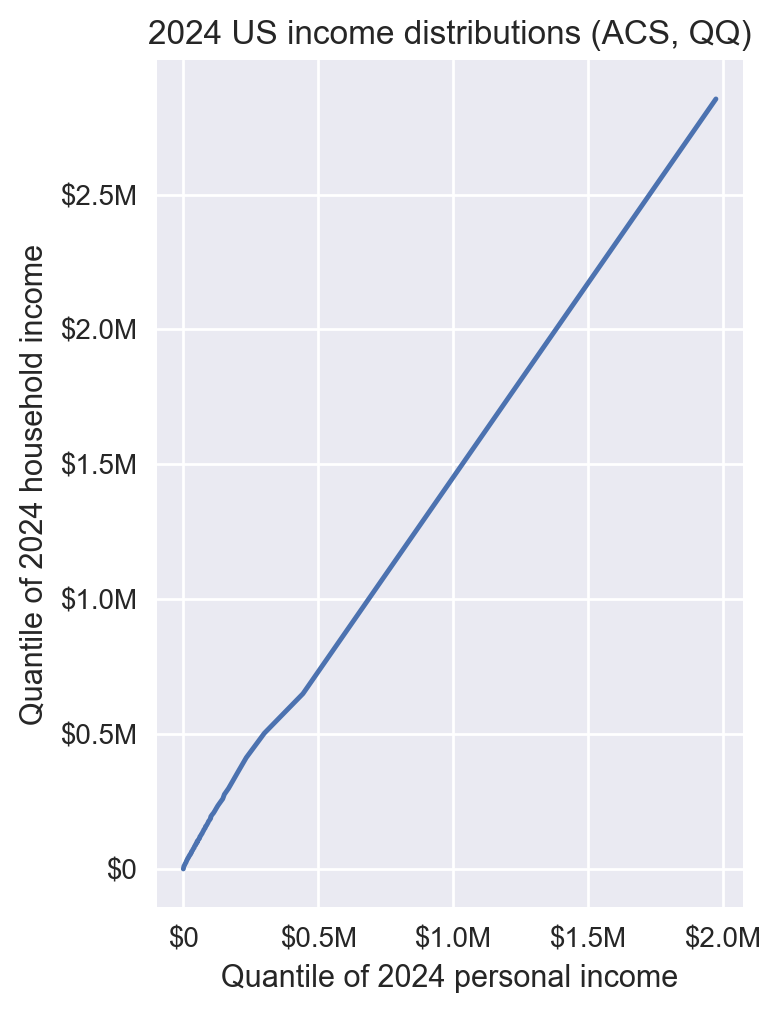

In [54]:
def millions(x, _):
    if x == 0:
        return '$0'
    else:
        return f'${(x/1_000_000):.1f}M'

plt.plot(qpersonal, qhousehold)

lims = 0, qpersonal.max()
#plt.plot(lims, lims, linestyle=':', color='gray')
plt.gca().set_aspect('equal', adjustable='box')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(millions))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(millions))

plt.xlabel('Quantile of 2024 personal income')
plt.ylabel('Quantile of 2024 household income')

plt.title('2024 US income distributions (ACS, QQ)')

plt.show()

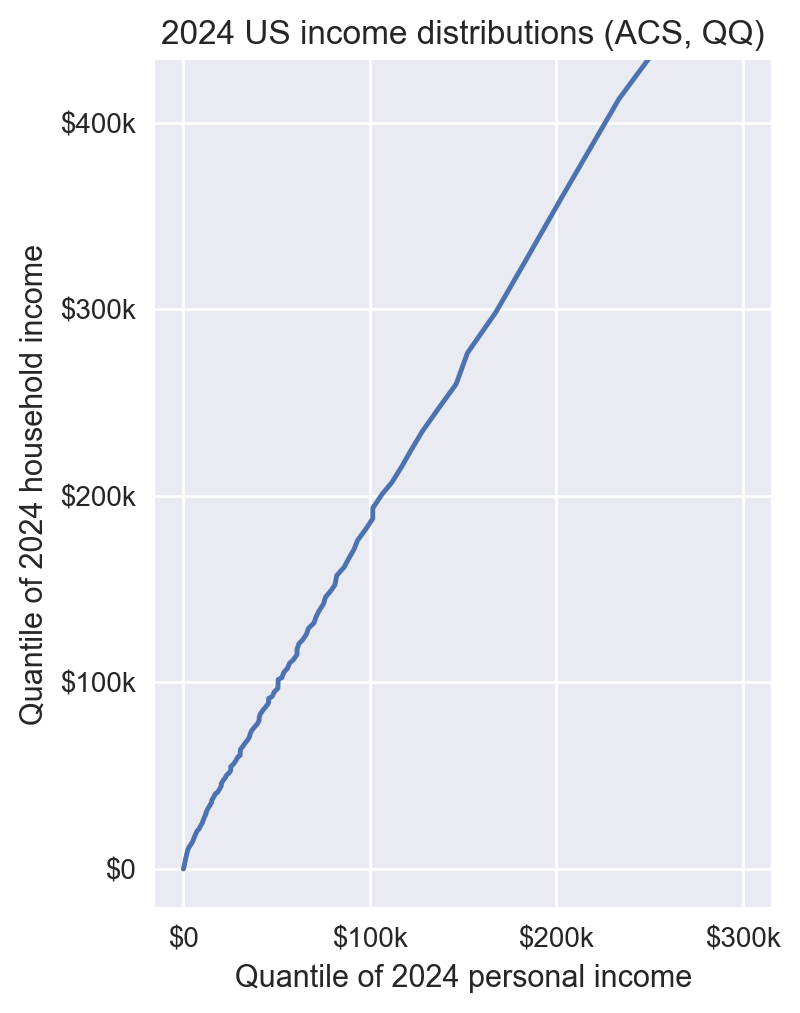

In [55]:
def thousands(x, _):
    if x == 0:
        return '$0'
    else:
        return f'${(x/1_000):.0f}k'

plt.plot(qpersonal[qpersonal <= 300_000], qhousehold[qpersonal <= 300_000])

lims = 0, 300_000
plt.plot(lims, lims, linestyle=':', color='gray')
plt.gca().set_aspect('equal', adjustable='box')
x, y = plt.xlim(), plt.ylim()
plt.close()
plt.plot(qpersonal, qhousehold)
lims = 0, 300_000
#plt.plot(lims, lims, linestyle=':', color='gray')
plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(x)
plt.ylim(y)
plt.xticks([0, 100_000, 200_000, 300_000])
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(thousands))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(thousands))

plt.xlabel('Quantile of 2024 personal income')
plt.ylabel('Quantile of 2024 household income')

plt.title('2024 US income distributions (ACS, QQ)')

plt.show()

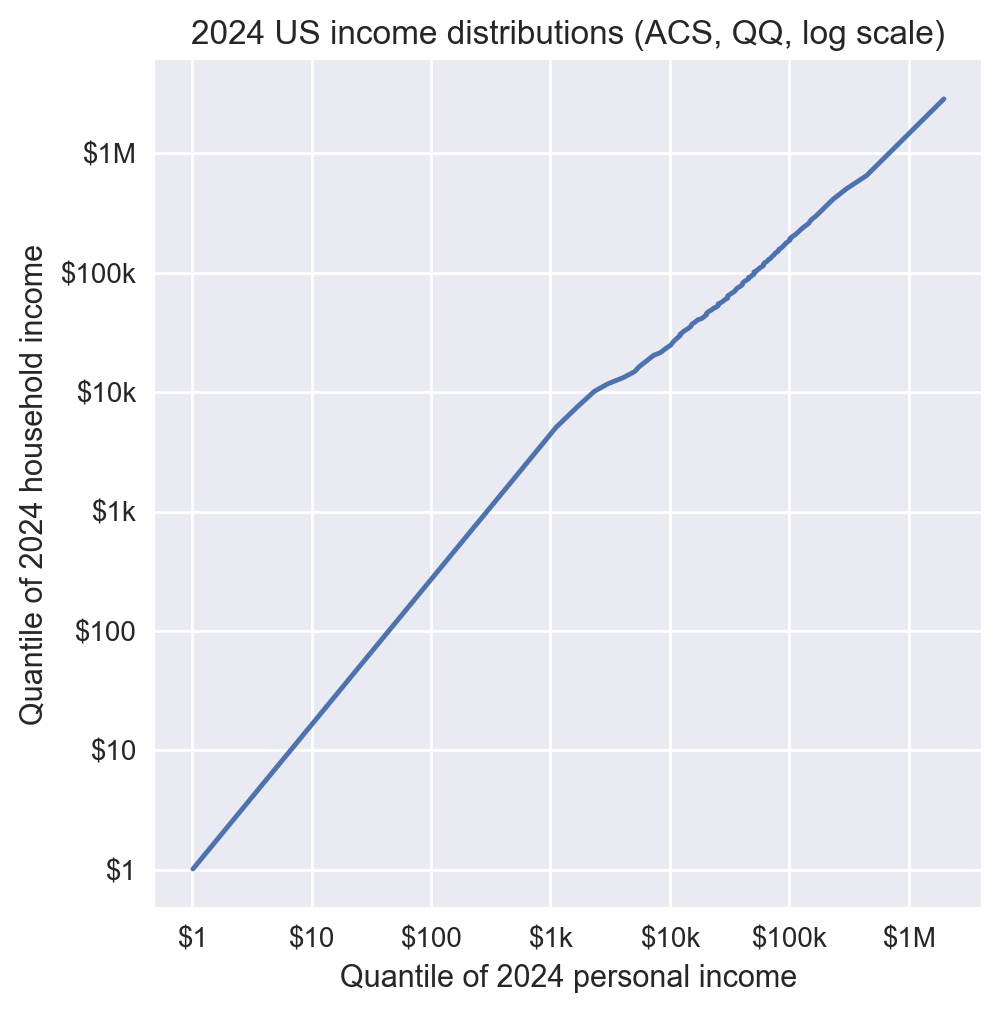

In [56]:
def adhoc(x, _):
    vals = {1: '$1', 10: '$10', 100: '$100', 1_000: '$1k', 10_000: '$10k', 100_000: '$100k', 1_000_000: '$1M'}
    return vals.get(x, 'no')

plt.loglog(qpersonal, qhousehold)

lims = 1, qpersonal.max()
#plt.plot(lims, lims, linestyle=':', color='gray')
plt.gca().set_aspect('equal', adjustable='box')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(adhoc))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(adhoc))

plt.xlabel('Quantile of 2024 personal income')
plt.ylabel('Quantile of 2024 household income')

plt.title('2024 US income distributions (ACS, QQ, log scale)')

plt.show()

In [40]:
x

array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04, 1.e+05,
       1.e+06, 1.e+07, 1.e+08])